In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np
import seaborn as sns

# Brand colors — DataViz-Wiz palette
TEAL = "#00C4A0"
PURPLE = "#7B5EA7"
NAVY = "#0A0A2E"
RED = "#E74C3C"
GREEN = "#27AE60"
GOLD = "#C9A84C"
GREY = "#95A5A6"

# Increase default font sizes for screen recording readability
plt.rcParams.update({'font.size': 12})

print("Setup complete — ready to build charts")

Setup complete — ready to build charts


In [2]:

import io
from PIL import Image
from matplotlib.animation import PillowWriter

def fig_to_pil(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=120, bbox_inches='tight', facecolor='white')
    buf.seek(0); img = Image.open(buf).copy(); buf.close(); plt.close(fig)
    return img

frames_h = []

# -- Chart 1 preview --
dates_h = pd.date_range("2024-01-01", periods=24, freq="ME")
dh = pd.DataFrame({"Date":dates_h, "North":np.cumsum(np.random.randn(24))+100,
                   "South":np.cumsum(np.random.randn(24))+90,
                   "East":np.cumsum(np.random.randn(24))+95,
                   "West":np.cumsum(np.random.randn(24))+85})
fig,ax = plt.subplots(figsize=(10,6),facecolor="white")
for col,color in zip(["North","South","East","West"],[TEAL,PURPLE,GOLD,RED]):
    ax.plot(dh["Date"],dh[col],label=col,color=color,linewidth=2.5)
ax.set_title("Chart 1 — Multi-Line Trend",fontsize=18,fontweight="bold",color=NAVY)
ax.legend(frameon=False); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
frames_h.extend([fig_to_pil(fig)]*50)  # 5 sec at 10fps

# -- Chart 2 preview --
metrics_h = ["Revenue","Expenses","Marketing","Customers","Satisfaction"]
corr_h = np.random.rand(5,5); corr_h=(corr_h+corr_h.T)/2; np.fill_diagonal(corr_h,1)
fig,ax = plt.subplots(figsize=(10,6),facecolor="white")
cmap_h = sns.diverging_palette(280,165,s=60,l=50,as_cmap=True)
sns.heatmap(pd.DataFrame(corr_h,columns=metrics_h,index=metrics_h),annot=True,
            fmt=".2f",cmap=cmap_h,center=0.5,linewidths=1,linecolor="white",ax=ax)
ax.set_title("Chart 2 — Correlation Heatmap",fontsize=18,fontweight="bold",color=NAVY)
plt.tight_layout()
frames_h.extend([fig_to_pil(fig)]*50)

# -- Chart 3 preview --
cats_h=["Start","New Sales","Upsells","Churn","Refunds","End"]
vals_h=[100,35,15,-20,-8,122]; tot_h=[True,False,False,False,False,True]
fig,ax=plt.subplots(figsize=(10,6),facecolor="white")
cum=0; bots=[]
for val, tot in zip(vals_h, tot_h):
    if tot:
        bots.append(0)
        running_total = val
    else:
        if val < 0:
            running_total += val  # Drop the baseline first for negative changes
            bots.append(running_total)
        else:
            bots.append(running_total)
            running_total += val  # Raise the baseline after for positive changes

cwf=[NAVY if t else (GREEN if v>=0 else RED) for v,t in zip(vals_h,tot_h)]
bars_h=ax.bar(cats_h,[abs(v) if not t else v for v,t in zip(vals_h,tot_h)],
              bottom=bots,color=cwf,width=0.6,edgecolor="white",linewidth=1.5)
for bar,v,t in zip(bars_h,vals_h,tot_h):
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_y()+bar.get_height()/2,
            f"+{v}" if v>0 and not t else str(v),ha="center",va="center",
            fontsize=10,fontweight="bold",color="white")
ax.set_title("Chart 3 — Waterfall / Revenue Bridge",fontsize=18,fontweight="bold",color=NAVY)
ax.spines[['top','right']].set_visible(False); plt.tight_layout()
frames_h.extend([fig_to_pil(fig)]*50)

# -- Chart 4 preview --
items_h=["Product Quality","Customer Support","Pricing","Ease of Use","Delivery","Communication","Value"]
sc_h=[45,-20,-35,60,25,-10,15]
sdf_h=pd.DataFrame({"Item":items_h,"Score":sc_h}).sort_values("Score")
fig,ax=plt.subplots(figsize=(10,6),facecolor="white")
bars_d=ax.barh(sdf_h["Item"],sdf_h["Score"],color=[RED if s<0 else TEAL for s in sdf_h["Score"]],height=0.6)
for bar,sc in zip(bars_d,sdf_h["Score"]):
    ax.text(sc+(2 if sc>=0 else -2),bar.get_y()+bar.get_height()/2,f"{sc:+d}%",
            va="center",ha="left" if sc>=0 else "right",fontsize=10,fontweight="bold",color=NAVY)
ax.axvline(0,color=NAVY,linewidth=1)
ax.set_title("Chart 4 — Diverging Bar (NPS Survey)",fontsize=18,fontweight="bold",color=NAVY)
ax.spines[['top','right']].set_visible(False); plt.tight_layout()
frames_h.extend([fig_to_pil(fig)]*50)

# -- Chart 5 preview (final frame of bar race) --
makers_h=["Tata","MG","Hyundai","Mahindra","Ola Electric"]
rcm={m:c for m,c in zip(makers_h,[TEAL,PURPLE,GOLD,RED,GREY])}
end_v_h={"Tata":850,"MG":620,"Hyundai":410,"Mahindra":540,"Ola Electric":780}
fd_h=pd.Series(end_v_h).sort_values(ascending=True)
fig,ax=plt.subplots(figsize=(10,6),facecolor="white")
b5=ax.barh(fd_h.index,fd_h.values,color=[rcm[m] for m in fd_h.index],height=0.6)
for bar,val in zip(b5,fd_h.values):
    ax.text(val+max(fd_h.values)*0.01,bar.get_y()+bar.get_height()/2,
            f"{val:,.0f}",va="center",fontsize=10,fontweight="bold",color=NAVY)
ax.set_xlim(0,max(fd_h.values)*1.15)
ax.set_title("Chart 5 — Bar Race: EV Sales 2023",fontsize=18,fontweight="bold",color=NAVY)
ax.spines[['top','right']].set_visible(False); plt.tight_layout()
frames_h.extend([fig_to_pil(fig)]*50)

# Save the D GIF — 5 charts × 5 seconds = 25-second opener
frames_h[0].save("Video02_D_AllCharts_Preview.gif", save_all=True,
                     append_images=frames_h[1:], duration=100, loop=0)
print("D GIF created: Video02_D_AllCharts_Preview.gif")

D GIF created: Video02_D_AllCharts_Preview.gif


---

In [3]:
# Sample dataset — used across all charts in this video
np.random.seed(42)
dates = pd.date_range("2024-01-01", periods=24, freq="ME")
df = pd.DataFrame({
    "Date": dates,
    "Region_North": np.cumsum(np.random.randn(24)) + 100,
    "Region_South": np.cumsum(np.random.randn(24)) + 90,
    "Region_East": np.cumsum(np.random.randn(24)) + 95,
    "Region_West": np.cumsum(np.random.randn(24)) + 85,
})
df.to_csv("sample_business_data.csv", index=False)
df.head()

,Date,Region_North,Region_South,Region_East,Region_West
0,2024-01-31,100.496714,89.455617,95.343618,84.964174
1,2024-02-29,100.358450,89.566540,93.580578,86.528818
2,2024-03-31,101.006138,88.415546,93.904662,83.909073
3,2024-04-30,102.529168,88.791244,93.519580,84.730975
4,2024-05-31,102.295015,88.190606,92.842658,84.818022


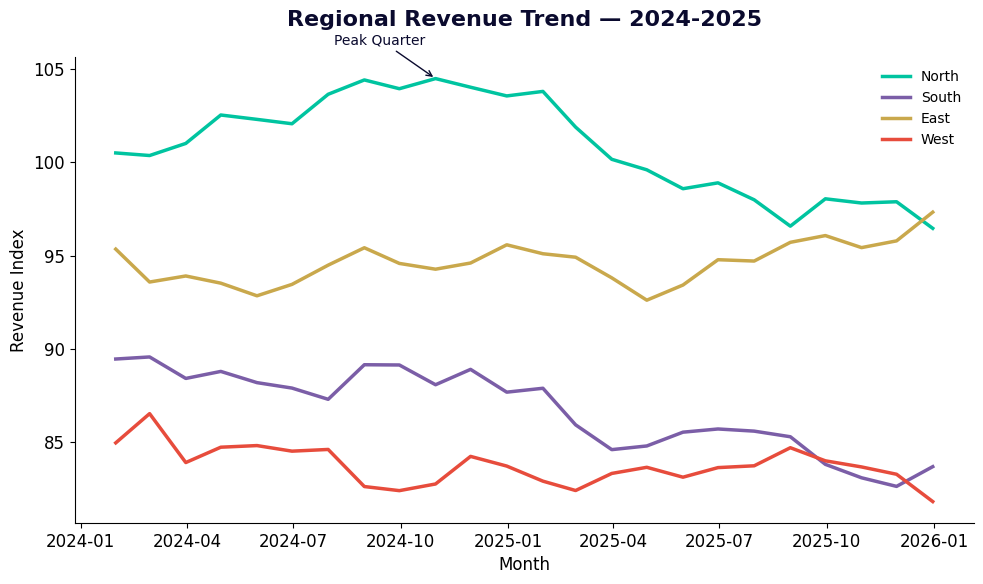

In [4]:
fig, ax = plt.subplots(figsize=(10,6), facecolor="white")
colors = [TEAL, PURPLE, GOLD, RED]

for col, color in zip(["Region_North", "Region_South", "Region_East", "Region_West"], colors):
    ax.plot(df["Date"], df[col], label=col.replace("Region_", ""), color=color, linewidth=2.5)

# Annotate the peak point — this is what makes the chart tell a story
peak_idx = df["Region_North"].idxmax()
ax.annotate("Peak Quarter", xy=(df["Date"][peak_idx], df["Region_North"][peak_idx]),
            xytext=(-40, 25), textcoords="offset points",ha='center', fontsize=10, color=NAVY,
            arrowprops=dict(arrowstyle="->", color=NAVY))

ax.set_title("Regional Revenue Trend — 2024-2025", fontsize=16, fontweight="bold", color=NAVY,y=1.05)
ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Revenue Index", fontsize=12)
ax.legend(frameon=False, fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig("chart1_multiline_trend.png", dpi=150)
plt.show()

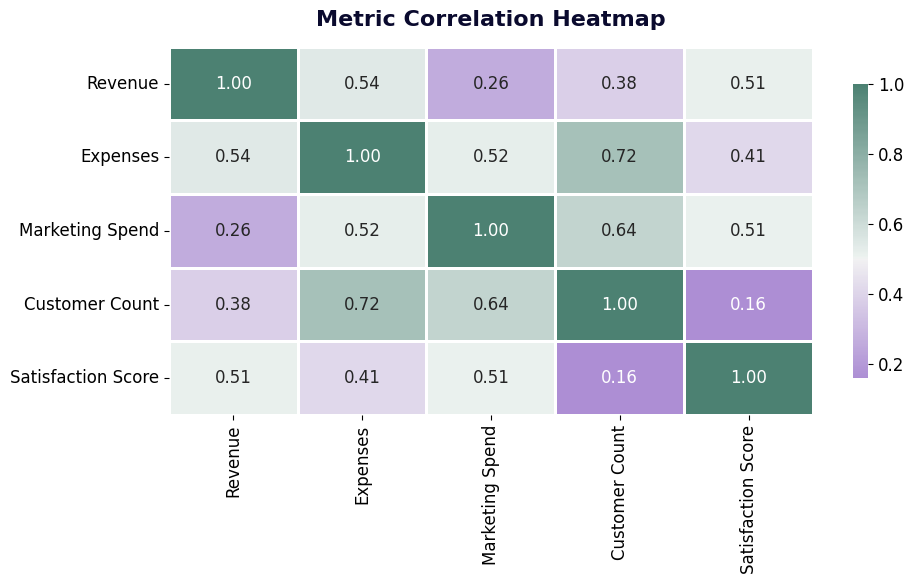

In [5]:
# Sample correlation data across 5 business metrics
metrics = ["Revenue", "Expenses", "Marketing Spend", "Customer Count", "Satisfaction Score"]
corr_data = np.random.rand(5, 5)
corr_data = (corr_data + corr_data.T) / 2  # make symmetric like a real correlation matrix
np.fill_diagonal(corr_data, 1)
corr_df = pd.DataFrame(corr_data, columns=metrics, index=metrics)

fig, ax = plt.subplots(figsize=(10,6), facecolor="white")
cmap = sns.diverging_palette(280, 165, s=60, l=50, as_cmap=True)  # purple to teal
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap=cmap, center=0.5,
            linewidths=1, linecolor="white", ax=ax, cbar_kws={"shrink": 0.8})

ax.set_title("Metric Correlation Heatmap", fontsize=16, fontweight="bold", color=NAVY, pad=15)
plt.tight_layout()
plt.savefig("chart2_heatmap.png", dpi=150)
plt.show()

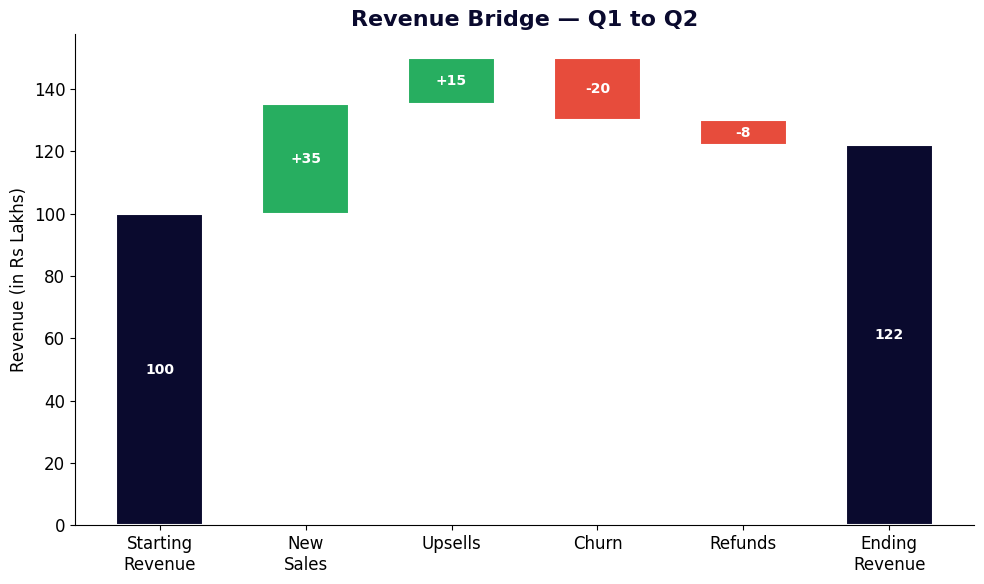

In [6]:
# Waterfall chart — revenue bridge from Q1 to Q2
categories = ["Starting\nRevenue", "New\nSales", "Upsells", "Churn", "Refunds", "Ending\nRevenue"]
values = [100, 35, 15, -20, -8, 122]
is_total = [True, False, False, False, False, True]

fig, ax = plt.subplots(figsize=(10,6), facecolor="white")

# Calculate where each bar should start (the "floating" bridge effect)
cumulative = 0
running_total = 0
bottoms = []
for val, tot in zip(values, is_total):
    if tot:
        bottoms.append(0)
        running_total = val
    else:
        if val < 0:
            running_total += val  # Drop the baseline first for negative changes
            bottoms.append(running_total)
        else:
            bottoms.append(running_total)
            running_total += val  # Raise the baseline after for positive changes

colors_wf = [NAVY if tot else (GREEN if val >= 0 else RED) for val, tot in zip(values, is_total)]
heights = [abs(v) if not is_total[i] else v for i, v in enumerate(values)]

bars = ax.bar(categories, heights, bottom=bottoms, color=colors_wf, width=0.6,
              edgecolor="white", linewidth=1.5)

# Label each bar with its value
for bar, val, tot in zip(bars, values, is_total):
    label = f"+{val}" if val > 0 and not tot else f"{val}"
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_y() + bar.get_height()/2,
            label, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

ax.set_title("Revenue Bridge — Q1 to Q2", fontsize=16, fontweight="bold", color=NAVY)
ax.set_ylabel("Revenue (in Rs Lakhs)", fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig("chart3_waterfall.png", dpi=150)
plt.show()

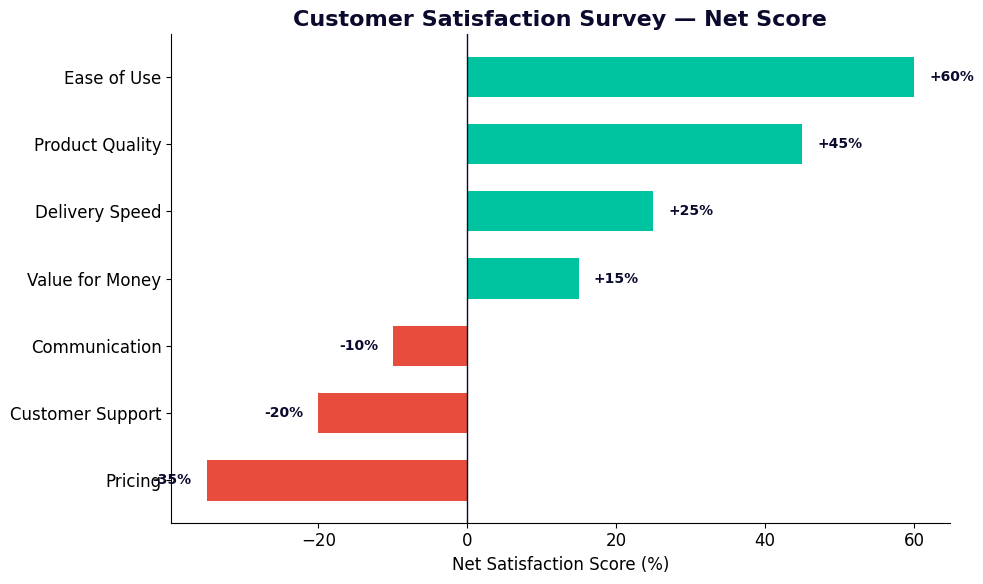

In [7]:
# Diverging bar chart — customer satisfaction survey results
survey_items = ["Product Quality", "Customer Support", "Pricing", "Ease of Use",
                "Delivery Speed", "Communication", "Value for Money"]
scores = [45, -20, -35, 60, 25, -10, 15]
survey_df = pd.DataFrame({"Item": survey_items, "Score": scores}).sort_values("Score")

fig, ax = plt.subplots(figsize=(10,6), facecolor="white")
colors_div = [RED if s < 0 else TEAL for s in survey_df["Score"]]
bars = ax.barh(survey_df["Item"], survey_df["Score"], color=colors_div, height=0.6)

for bar, score in zip(bars, survey_df["Score"]):
    x_pos = score + (2 if score >= 0 else -2)
    ha = "left" if score >= 0 else "right"
    ax.text(x_pos, bar.get_y() + bar.get_height()/2, f"{score:+d}%",
            va="center", ha=ha, fontsize=10, fontweight="bold", color=NAVY)

ax.axvline(0, color=NAVY, linewidth=1)
ax.set_title("Customer Satisfaction Survey — Net Score", fontsize=16, fontweight="bold", color=NAVY)
ax.set_xlabel("Net Satisfaction Score (%)", fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig("chart4_diverging_bar.png", dpi=150)
plt.show()

Animation saved as chart5_ev_bar_race.gif — open this file to preview/screen-record it


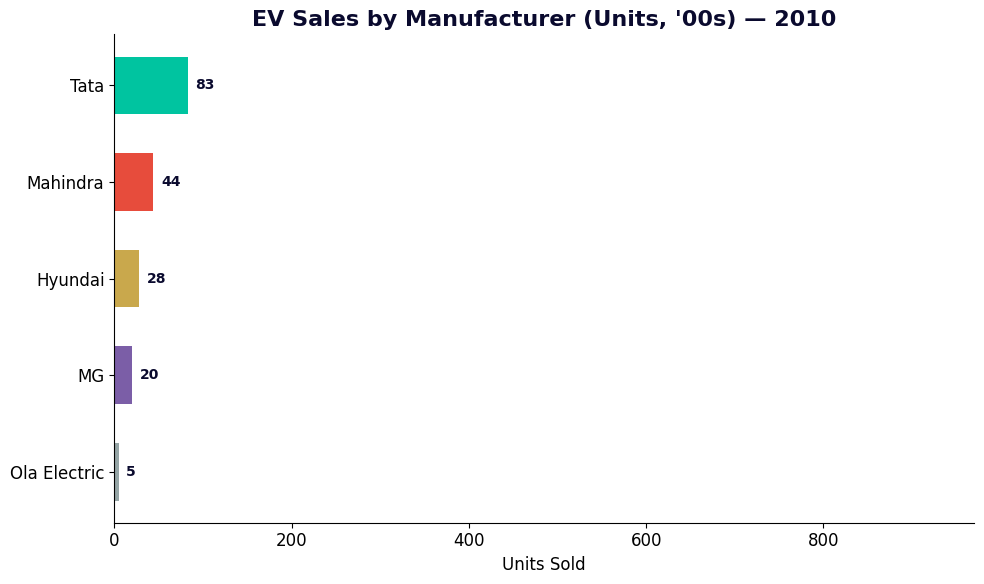

In [8]:
# Chart 5 — Animated Bar Chart Race — EV Sales by Manufacturer 2010-2023
# This is a real, tested FuncAnimation build. Replace with your actual Video 1
# dataset/notebook if you want to reuse the exact same data and render already used.
from matplotlib.animation import FuncAnimation, PillowWriter

makers = ["Tata", "MG", "Hyundai", "Mahindra", "Ola Electric"]
race_colors_map = {m: c for m, c in zip(makers, [TEAL, PURPLE, GOLD, RED, GREY])}
years = list(range(2010, 2024))

# Sample EV sales data — replace with your real dataset if available
np.random.seed(7)
start_vals = {"Tata": 40, "MG": 25, "Hyundai": 15, "Mahindra": 35, "Ola Electric": 5}
end_vals   = {"Tata": 850, "MG": 620, "Hyundai": 410, "Mahindra": 540, "Ola Electric": 780}
rows = []
for m in makers:
    t = np.linspace(0, 1, len(years))
    curve = start_vals[m] + (end_vals[m] - start_vals[m]) * (t ** 1.6)
    noise = np.random.normal(0, curve.max() * 0.03, len(years))
    vals = np.maximum(curve + noise, 5)
    for y, v in zip(years, vals):
        rows.append({"Year": y, "Maker": m, "Sales": v})

ev_df = pd.DataFrame(rows)
ev_df.to_csv("ev_sales_data.csv", index=False)
pivot = ev_df.pivot(index="Year", columns="Maker", values="Sales")

fig, ax = plt.subplots(figsize=(10,6), facecolor="white")

def update(year):
    ax.clear()
    frame_data = pivot.loc[year].sort_values(ascending=True)
    bar_colors = [race_colors_map[m] for m in frame_data.index]
    bars = ax.barh(frame_data.index, frame_data.values, color=bar_colors, height=0.6)
    for bar, val in zip(bars, frame_data.values):
        ax.text(val + pivot.values.max()*0.01, bar.get_y() + bar.get_height()/2,
                 f"{val:,.0f}", va="center", fontsize=10, fontweight="bold", color=NAVY)
    ax.set_xlim(0, pivot.values.max() * 1.15)
    ax.set_title(f"EV Sales by Manufacturer (Units, '00s) — {year}", fontsize=16, fontweight="bold", color=NAVY)
    ax.set_xlabel("Units Sold", fontsize=12)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()

# Build and save the animation as a GIF — takes a few seconds to render
anim = FuncAnimation(fig, update, frames=years, interval=600, repeat=False)
anim.save("chart5_ev_bar_race.gif", writer=PillowWriter(fps=2))
print("Animation saved as chart5_ev_bar_race.gif — open this file to preview/screen-record it")

# Show final frame inline for a quick static check
update(years[-1])
plt.savefig("chart5_bar_race_final_frame.png", dpi=150)
plt.show()